# Car Price Prediction - EDA
Cilj ovog notebooka je da istrazim skup podataka o polovnim automobilima,prepoznam probleme i pripremim osnovu za dalje korake kao sto su:ciscenje,feature engineering i modeliranje.

In [1]:
from google.colab import files
uploaded =files.upload()

Saving cars.csv to cars.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)

## Osnovne informacije o skupu podataka

In [5]:
podaci = pd.read_csv('cars.csv')
print("Broj redova i kolona:",podaci.shape)
print("\nPrvih 5 redova:")
print(podaci.head())
print("\nTipovi podataka:")
print(podaci.dtypes)
print("\nBroj nedostajucih vrijednosti po koloni:")
print(podaci.isnull().sum())

Broj redova i kolona: (56244, 12)

Prvih 5 redova:
    make model  priceUSD  year     condition  mileage(kilometers) fuel_type  \
0  mazda     2      5500  2008  with mileage             162000.0    petrol   
1  mazda     2      5350  2009  with mileage             120000.0    petrol   
2  mazda     2      7000  2009  with mileage              61000.0    petrol   
3  mazda     2      3300  2003  with mileage             265000.0    diesel   
4  mazda     2      5200  2008  with mileage              97183.0    diesel   

   volume(cm3)     color transmission         drive_unit segment  
0       1500.0  burgundy    mechanics  front-wheel drive       B  
1       1300.0     black    mechanics  front-wheel drive       B  
2       1500.0    silver         auto  front-wheel drive       B  
3       1400.0     white    mechanics  front-wheel drive       B  
4       1400.0      gray    mechanics  front-wheel drive       B  

Tipovi podataka:
make                    object
model                  

## Analiza ciljne promjenjive-priceUSD
Prije bilo cega drugog,gledam kako je rasporedjena cijena,jer je to ono sto model treba da predvidja.

Statistika za priceUSD:
count     56244.000000
mean       7415.456440
std        8316.959261
min          48.000000
25%        2350.000000
50%        5350.000000
75%        9807.500000
max      235235.000000
Name: priceUSD, dtype: float64


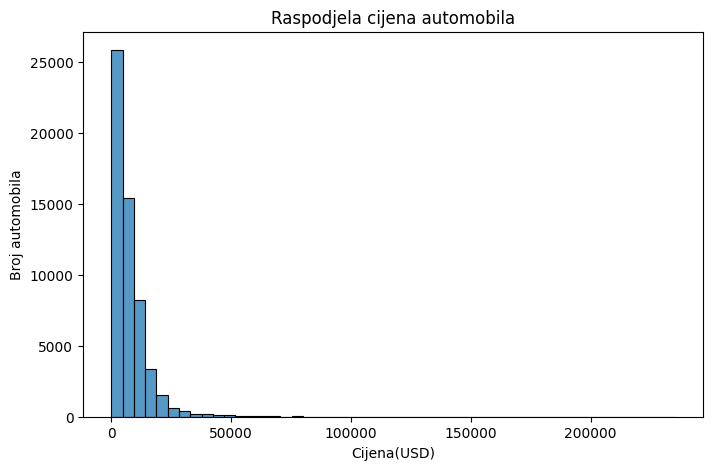

In [6]:
print('Statistika za priceUSD:')
print(podaci['priceUSD'].describe())
plt.figure(figsize=(8,5))
sns.histplot(podaci['priceUSD'],bins=50)
plt.title('Raspodjela cijena automobila')
plt.xlabel('Cijena(USD)')
plt.ylabel('Broj automobila')
plt.show()


## Analiza numerickih kolona(year,mileage,volume)

In [11]:
print("Statistika za year:")
print(podaci['year'].describe())
print("\nStatitika za mileage(kilometers):")
print(podaci['mileage(kilometers)'].describe())
print("\nStatistika za volume:")
print(podaci['volume(cm3)'].describe())

Statistika za year:
count    56244.000000
mean      2003.454840
std          8.144247
min       1910.000000
25%       1998.000000
50%       2004.000000
75%       2010.000000
max       2019.000000
Name: year, dtype: float64

Statitika za mileage(kilometers):
count    5.624400e+04
mean     2.443956e+05
std      3.210307e+05
min      0.000000e+00
25%      1.370000e+05
50%      2.285000e+05
75%      3.100000e+05
max      9.999999e+06
Name: mileage(kilometers), dtype: float64

Statistika za volume:
count    56197.000000
mean      2104.860615
std        959.201633
min        500.000000
25%       1600.000000
50%       1996.000000
75%       2300.000000
max      20000.000000
Name: volume(cm3), dtype: float64


## ANaliza kategorijskih kolona

In [12]:
kategorijske_kolone = ['make', 'condition', 'fuel_type', 'transmission', 'drive_unit', 'segment', 'color']
for kolona in kategorijske_kolone:
  print(f"\n---{kolona}---")
  print(podaci[kolona].value_counts())


---make---
make
volkswagen    6861
audi          4030
bmw           4013
opel          3779
renault       3713
              ... 
mclaren          1
asia             1
jac              1
tagaz            1
saipa            1
Name: count, Length: 96, dtype: int64

---condition---
condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64

---fuel_type---
fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64

---transmission---
transmission
mechanics    36056
auto         20188
Name: count, dtype: int64

---drive_unit---
drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel drive                5890
part-time four-wheel drive     3597
Name: count, dtype: int64

---segment---
segment
D    12605
C    10617
J     8629
M     6313
E     6274
B     4393
F      896
S      765
A      461
Name: count, dtype: int64

---color---
color
black       12385
silver      10075
blue 

## Uocavanje problema u podacima
Provjeravam ekstremne vrijednosti koje bi mogle biti greske u unosu podataka,i koje bi mogle nepotrebno zbuniti model.

In [13]:
print("Broj automobila sa cijenom <=100$:",(podaci['priceUSD']<=100).sum())
print("Broj automobila sa cijenom >=100000$:",(podaci['priceUSD']>=100000).sum())
print("\nBroj automobila sa godinom prije 1950:",(podaci['year']<1950).sum())
print(podaci[podaci['year']<1950]['year'].value_counts().sort_index())
print("\nBroj automobila sa kilometrazom preko 1000000 km:",(podaci['mileage(kilometers)']>1000000).sum())
print('\nBroj automobila sa zapreminom preko 6000 cm3:',(podaci['volume(cm3)']>6000).sum())


Broj automobila sa cijenom <=100$: 9
Broj automobila sa cijenom >=100000$: 33

Broj automobila sa godinom prije 1950: 8
year
1910    1
1933    1
1936    1
1938    1
1942    1
1945    1
1948    1
1949    1
Name: count, dtype: int64

Broj automobila sa kilometrazom preko 1000000 km: 364

Broj automobila sa zapreminom preko 6000 cm3: 122


## Zakljucak EDA analize

Skup podataka na kojem sam radio ima  56244 automobila i 12 kolona.Ciljna promjenljiva priceUSD je desno asimetricna.Problemi koje sam uocio su:
- 9 automobila sa gotovo nultom cijenom
- 33 automobila sa ekstremnom cijenom
- 8 automobila sa godinom proizvodnje prije 1950
- 364 automobila sa kilometrazom preko milion km
- 122 automobila sa zapreminom motora preko 6000 cm3
- Nedostacuje vrijednosti u volume(cm3),drive_unit i segment

Sve ovo cu rijesiti u skripti data_cleaning.py u iducem koraku.